In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
print(df.shape)

print(df.info())

print(df.isnull().sum())

(7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null

In [7]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

df["TotalCharges"] = df["TotalCharges"].fillna(
    df["TotalCharges"].median()
)

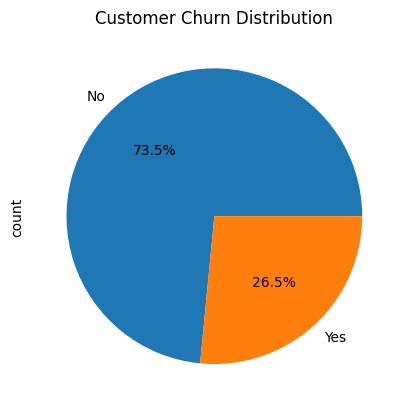

In [8]:
churn_counts = df["Churn"].value_counts()

churn_counts.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Customer Churn Distribution")

plt.show()

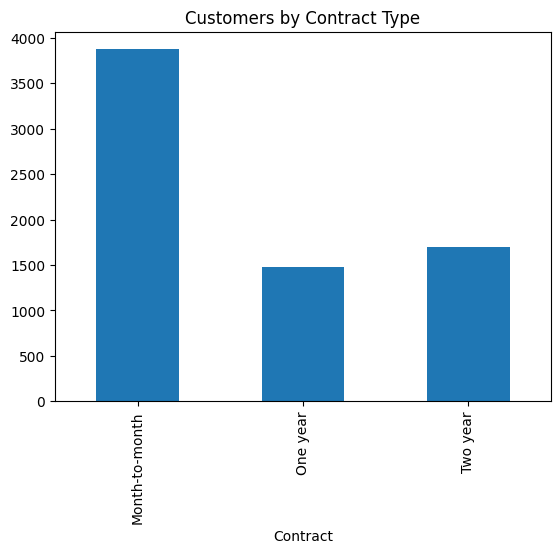

In [9]:
contract = (
    df.groupby("Contract")["customerID"]
      .count()
)

contract.plot(
    kind="bar"
)

plt.title("Customers by Contract Type")

plt.show()

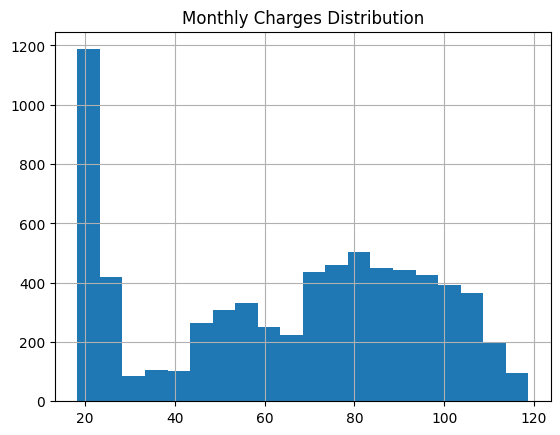

In [10]:
df["MonthlyCharges"].hist(
    bins=20
)

plt.title("Monthly Charges Distribution")

plt.show()

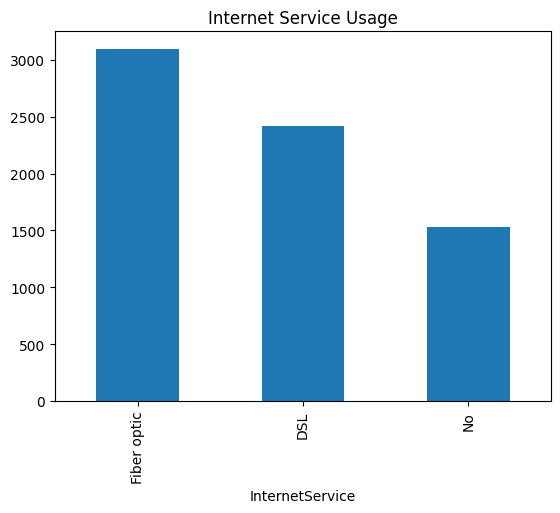

In [11]:
internet = (
    df["InternetService"]
      .value_counts()
)

internet.plot(
    kind="bar"
)

plt.title("Internet Service Usage")

plt.show()

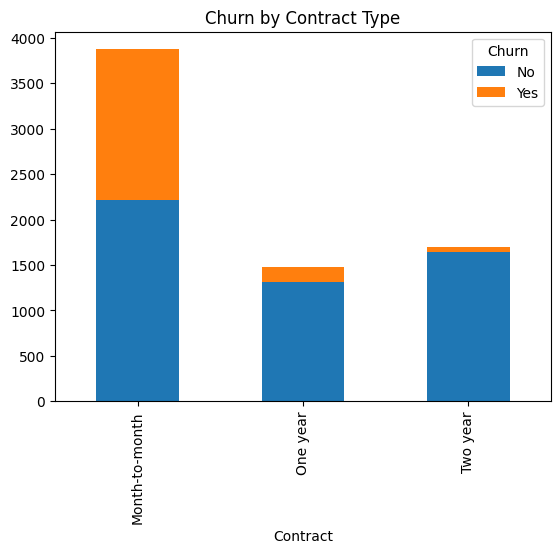

In [12]:
pd.crosstab(
    df["Contract"],
    df["Churn"]
).plot(
    kind="bar",
    stacked=True
)

plt.title("Churn by Contract Type")

plt.show()

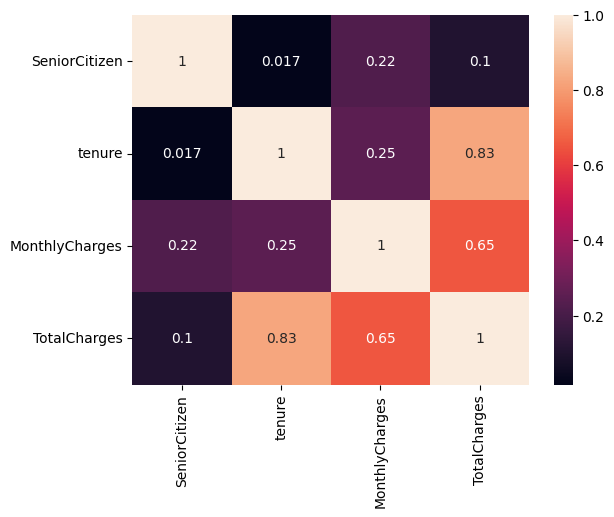

In [13]:
import seaborn as sns

numeric_df = df.select_dtypes(
    include=np.number
)

sns.heatmap(
    numeric_df.corr(),
    annot=True
)

plt.show()

In [14]:
from sklearn.preprocessing import LabelEncoder

df_ml = df.copy()

le = LabelEncoder()

for col in df_ml.columns:
    if df_ml[col].dtype == "object":
        df_ml[col] = le.fit_transform(
            df_ml[col].astype(str)
        )

In [15]:
X = df_ml.drop(
    ["Churn"],
    axis=1
)

y = df_ml["Churn"]

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [17]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()

model.fit(
    X_train,
    y_train
)

RandomForestClassifier()

In [18]:
from sklearn.metrics import accuracy_score

predictions = model.predict(
    X_test
)

accuracy = accuracy_score(
    y_test,
    predictions
)

print(
    "Accuracy:",
    accuracy
)

Accuracy: 0.7955997161107168


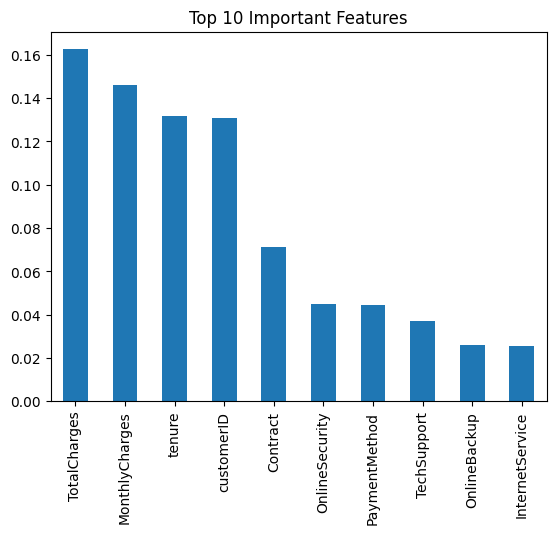

In [19]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)

importance.sort_values(
    ascending=False
).head(10).plot(
    kind="bar"
)

plt.title(
    "Top 10 Important Features"
)

plt.show()